In [1]:
import numpy as np
import scipy.io
import pydot
import graphviz
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.tree import export_graphviz
from sklearn.cross_validation import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.cross_validation import cross_val_score
from sklearn.ensemble import AdaBoostClassifier

In [24]:
# sample_installed = np.random.choice(10000, 5000, replace=False)
# sample_unstalled = sample_installed + 10000
# data_combined = pd.concat([data_combined.iloc[sample_installed, :], data_combined.iloc[sample_unstalled, :]])

In [168]:
def get_importance(rf):
    # Get numerical feature importances
    importances = list(rf.feature_importances_)
    # List of tuples with variable and importance
    feature_importances = [(feature, round(importance, 2)) for feature, importance in zip(feature_list, importances)]
    # Sort the feature importances by most important first
    feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)
    # Print out the feature and importances 
#     for pair in feature_importances:
#         print('Variable: {:20} Importance: {}'.format(*pair))
    return feature_importances

In [169]:
def get_graph(rf):
    # Pull out one tree from the forest
    tree = rf.estimators_[np.random.choice(len(rf.estimators_))]
    # Export the image to a dot file
    # export_graphviz(tree, out_file = 'tree.dot', feature_names = feature_list, rounded = True, precision = 1)
    export_graphviz(tree, out_file = 'tree.dot', feature_names = feature_list, rounded = True)
    # Use dot file to create a graph
    (graph, ) = pydot.graph_from_dot_file('tree.dot')
    # Write graph to a png file
    graph.write_png('tree.png')

In [170]:
def feature_important(n, feature_importances, feature_list, train_features, test_features):
    # Extract the ten most important features
    important_indices = list()
    for pair in feature_importances[:n]:
        important_indices.append(feature_list.index(pair[0]))
    train_important = train_features[:, important_indices]
    test_important = test_features[:, important_indices]
    return train_important, test_important

In [17]:
#"City" "Efficiency" "AddressLine1"

In [209]:
data_combined = pd.read_csv("/Users/apple/Documents/Hackthon/Suncode 2018/suncode/all_joined.csv")

In [210]:
drop_list = ["yearly_sunlight_kwh_total", "yearly_sunlight_kwh_f", "yearly_sunlight_kwh_n", "yearly_sunlight_kwh_e",
             "yearly_sunlight_kwh_w", "yearly_sunlight_kwh_median", "yearly_sunlight_kwh_kw_threshold_avg", 
             "JobId", "EngineeringSoldkWSize", 'Zip',
             "EnergyConsumption", "Region", "State", "PowerwallCount", "UtilityRatePlanId", 
             "UtilityInflationRate","Bedroom", "HeatingType", "Heating", "CoolingType", "Cooling", "AHJ", "NumStories",
             "Avg.Age.Male", "Avg..Age.Female", "HS.or.Below", "Undergrad.or.Below", "Graduate.School"]
for drop_name in drop_list:
    data_combined = data_combined.drop(drop_name, axis=1)

In [211]:
data_combined.columns

Index([u'AverageTilt', u'PaymentType', u'GrossPrice', u'FederalTaxCredit',
       u'HomeSqFoot', u'YearBuilt', u'EngineeringSoldAnnualkWh', u'RoofType',
       u'RoofSqFoot', u'NumMountingPlanes', u'NumPanels', u'Utility',
       u'ProductTypeAlt', u'UtilityCostPerKWh', u'OldBill', u'GasRatePlanID',
       u'AverageShading', u'Status', u'Insolation', u'yearly_sunlight_kwh_s',
       u'Avg.Age', u'Total.Homes', u'Avg.Value', u'Median.Income',
       u'Population'],
      dtype='object')

In [212]:
expensive_drop_list = ["PaymentType", "RoofSqFoot", "GrossPrice", "NumMountingPlanes", "AverageShading"]
for drop_name in expensive_drop_list:
    data_combined = data_combined.drop(drop_name, axis=1)

In [213]:
# desc_list = ['RoofType', 'Utility', 'ProductTypeAlt', 
#              'GasRatePlanID', 'Avg.Age', 'PaymentType']
desc_list = ['Utility', 'ProductTypeAlt', 'GasRatePlanID', 'Avg.Age', 'RoofType']
# 'Region' 'Median.Income' 'State' 'UtilityRatePlanId' 'NumStories'
frame = list()
for indx, col_name in enumerate(desc_list):
    temp = pd.get_dummies(data_combined[col_name])
    data_combined = data_combined.drop(col_name, axis=1)
    frame.append(temp)
frame = [data_combined] + frame
data_combined = pd.concat(frame, axis=1)
    
# temp1 = pd.get_dummies(data_combined['UtilityRatePlanId'])
# temp2 = pd.get_dummies(data_combined['GasRatePlanID'])
# temp3 = pd.get_dummies(data_combined['State'])
# temp4 = 
# data_combined = data_combined.drop('UtilityRatePlanId',axis=1)
# data_combined = data_combined.drop('GasRatePlanID',axis=1)
# data_combined = data_combined.drop('State',axis=1)
# frame = [data_combined, temp1, temp2, temp3]
# data_combined = pd.concat(frame, axis=1)

In [214]:
for i in range(len(data_combined["YearBuilt"])):
    if data_combined["YearBuilt"][i] < 1950.0:
        data_combined.set_value(i, "YearBuilt", 1)
    elif data_combined["YearBuilt"][i] < 2000.0:
        data_combined.set_value(i, "YearBuilt", 2)
    else:
        data_combined.set_value(i, "YearBuilt", 3)

In [215]:
data_combined = data_combined.fillna(0)
data_combined

,AverageTilt,FederalTaxCredit,HomeSqFoot,YearBuilt,EngineeringSoldAnnualkWh,NumPanels,UtilityCostPerKWh,OldBill,Status,Insolation,...,Concrete - Pitched w/ Tile,Flat Tile,Foam,Metal - Standing Seam,Metal - Tile,Mixed Surfaces,Rolled Roofing / Torchdown / Bitumen,Round Tile,Spanish Tile Roof,Unknown roof
0,31,12093.9000,2686,3.0,7005.7898,28,0.206272,239.2864,1,3.67,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,14,9244.8000,1248,2.0,7154.6862,24,0.208386,180.1813,1,3.67,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,35,13389.6750,2132,1.0,8360.0471,31,0.201606,193.5778,0,3.67,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,26,17294.9250,2750,3.0,11727.1580,36,0.162062,233.6721,0,3.70,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,17,17719.2000,1400,2.0,11897.4318,46,0.194936,232.2442,1,3.70,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,35,3887.3250,1025,2.0,3496.7997,9,0.219422,117.3874,0,3.70,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,36,14703.3750,2580,1.0,7330.6948,30,0.206072,241.9167,0,3.70,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,31,16948.8000,2200,2.0,12630.1825,44,0.205831,289.2412,1,3.70,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,24,12561.8250,2183,1.0,7348.5437,24,0.207680,207.3161,1,3.67,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,26,7318.8000,1900,3.0,6114.5096,19,0.208141,155.2792,1,3.67,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [216]:
data_combined.to_csv("zillow_dropclean_cheap.csv")

In [217]:
# # One-hot encode the data using pandas get_dummies
# data_combined = pd.get_dummies(data_combined)
# # Display the first 5 rows of the last 12 columns
# data_combined.iloc[:,5:].head(5)

In [218]:
# Record outputs
outputs = np.array(data_combined['Status'])
# Drop the output columns
data_combined= data_combined.drop('Status', axis = 1)

In [219]:
# Saving feature names for later use
feature_list = list(data_combined.columns)
feature_list

['AverageTilt',
 'FederalTaxCredit',
 'HomeSqFoot',
 'YearBuilt',
 'EngineeringSoldAnnualkWh',
 'NumPanels',
 'UtilityCostPerKWh',
 'OldBill',
 'Insolation',
 'yearly_sunlight_kwh_s',
 'Total.Homes',
 'Avg.Value',
 'Median.Income',
 'Population',
 'Allegheny (Potomac Edison MD)',
 'Anaheim Public Utilities Department',
 'Arizona Public Service Company',
 'Atlantic City Electric',
 'Austin Energy (City of Austin)',
 'BGE (Baltimore Gas and Electric)',
 'Banning Electric Department',
 'Burbank Water and Power',
 'Burlington Electric Department',
 'Central Hudson Gas & Electric',
 'Choptank Electric',
 'City of Dover',
 'City of Milford',
 'City of Newark',
 'City of Redding Electric Utility',
 'Colorado Springs',
 'Colton Electric Utility',
 'Consolidated Edison',
 'Delaware Electric Cooperative',
 'Delmarva Power (DE)',
 'Delmarva Power (MD)',
 'Dominion Virginia Power',
 'Duke Energy (FL)',
 'Duquesne',
 'El Paso Electric Company (New Mexico)',
 'El Paso Electric Company (Texas)',
 'El

In [220]:
# Convert to numpy array
data_combined = np.array(data_combined)

In [221]:
# Split the data into training and testing sets
train_features, test_features, train_labels, test_labels = train_test_split(data_combined, outputs, 
                                                                            test_size = 0.25, random_state = 1)

# AdaBoost RF

In [222]:
adaRF = AdaBoostClassifier(n_estimators=700, random_state = 8001)
adaRF.fit(train_features, train_labels)
predictions = adaRF.predict(test_features)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        predictions[i] = 1
    else:
        predictions[i] = 0
errors = float(sum(abs(predictions - test_labels)))/len(test_labels)
errors

0.2437619961612284

In [223]:
np.savetxt("ADRFpred_cheap.csv", predictions, delimiter=",", header="Prediction")
np.savetxt("ADRFtrue_cheap.csv", test_labels, delimiter=",", header="True")

Running 100 estimators
Running 200 estimators
Running 300 estimators
Running 400 estimators
Running 500 estimators
Running 600 estimators
Running 700 estimators
Running 800 estimators
Running 900 estimators
Running 1000 estimators
0.225207933461


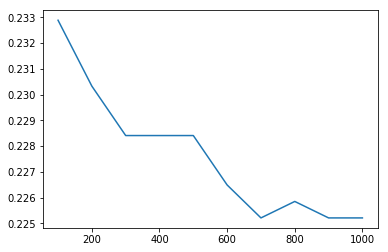

In [161]:
n_est = np.linspace(100, 1000, 10, dtype="int")
error_list = list()
for n in n_est:
    print("Running {} estimators".format(n))
    feature_importances = get_importance(adaRF)
    train_important, test_important = feature_important(8, feature_importances, feature_list, train_features, test_features)
    # New random forest with only the two most important variables
    adrf_most_important = RandomForestRegressor(n_estimators=n, random_state=8001)
    # Train the random forest
    adrf_most_important.fit(train_important, train_labels)
    # Make predictions and determine the error
    predictions = adrf_most_important.predict(test_important)
    for i in range(len(predictions)):
        if predictions[i] >= 0.5:
            predictions[i] = 1
        else:
            predictions[i] = 0
    errors = sum(abs(predictions - test_labels))/len(test_labels)
    error_list.append(errors)
    # Display the performance metrics
#     print('AdaBoost RF Mean Absolute Error:', round(np.mean(errors), 2))
plt.plot(n_est, error_list)
print(np.min(error_list))

# Random Forest

In [224]:
rf = RandomForestRegressor(n_estimators = 800, random_state = 8001)

# Training
rf.fit(train_features, train_labels)
# Make predictions and determine the error
predictions = rf.predict(test_features)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        predictions[i] = 1
    else:
        predictions[i] = 0
errors = sum(abs(predictions - test_labels))/len(test_labels)
errors

0.22328854766474729

In [225]:
np.savetxt("RFpred_cheap.csv", predictions, delimiter=",", header="Prediction")
np.savetxt("RFtrue_cheap.csv", test_labels, delimiter=",", header="True")

In [228]:
feature_importances = get_importance(rf)
feature_importances

[('EngineeringSoldAnnualkWh', 0.09),
 ('HomeSqFoot', 0.08),
 ('UtilityCostPerKWh', 0.07),
 ('OldBill', 0.07),
 ('AverageTilt', 0.05),
 ('FederalTaxCredit', 0.05),
 ('NumPanels', 0.04),
 ('Total.Homes', 0.04),
 ('Avg.Value', 0.04),
 ('Median.Income', 0.04),
 ('Population', 0.04),
 ('Insolation', 0.03),
 ('YearBuilt', 0.02),
 ('yearly_sunlight_kwh_s', 0.01),
 ('Sacramento Municipal Utility District', 0.01),
 ('Allegheny (Potomac Edison MD)', 0.0),
 ('Anaheim Public Utilities Department', 0.0),
 ('Arizona Public Service Company', 0.0),
 ('Atlantic City Electric', 0.0),
 ('Austin Energy (City of Austin)', 0.0),
 ('BGE (Baltimore Gas and Electric)', 0.0),
 ('Banning Electric Department', 0.0),
 ('Burbank Water and Power', 0.0),
 ('Burlington Electric Department', 0.0),
 ('Central Hudson Gas & Electric', 0.0),
 ('Choptank Electric', 0.0),
 ('City of Dover', 0.0),
 ('City of Milford', 0.0),
 ('City of Newark', 0.0),
 ('City of Redding Electric Utility', 0.0),
 ('Colorado Springs', 0.0),
 ('Co

In [167]:
n_est = np.linspace(600, 1800, 12, dtype="int")
error_list = list()
for n in n_est:
    print("Running {} estimators".format(n))
    feature_importances = get_importance(rf)
    train_important, test_important = feature_important(10, feature_importances, feature_list, 
                                                        train_features, test_features)
    # New random forest with only the two most important variables
    rf_most_important = RandomForestRegressor(n_estimators= n, random_state=8001)
    # Train the random forest
    rf_most_important.fit(train_important, train_labels)
    # Make predictions and determine the error
    predictions = rf_most_important.predict(test_important)
    for i in range(len(predictions)):
        if predictions[i] >= 0.5:
            predictions[i] = 1
        else:
            predictions[i] = 0
    errors = sum(abs(predictions - test_labels))/len(test_labels)
    error_list.append(errors)
    # Display the performance metrics
#     print('Mean Absolute Error:', round(np.mean(errors), 2))
plt.plot(n_est, error_list)
plt.xlabel("# of Estimators")
plt.ylabel("Error")
print(np.min(error_list))

Running 600 estimators


KeyboardInterrupt: 

In [27]:
get_graph(rf)

Variable: RoofSqFoot           Importance: 0.09
Variable: EngineeringSoldAnnualkWh Importance: 0.08
Variable: UtilityCostPerKWh    Importance: 0.08
Variable: NumPanels            Importance: 0.07
Variable: EngineeringSoldkWSize Importance: 0.06
Variable: AverageShading       Importance: 0.06
Variable: EnergyConsumption    Importance: 0.05
Variable: OldBill              Importance: 0.05
Variable:              40003.0 Importance: 0.03
Variable: NumMountingPlanes    Importance: 0.02
Variable: PV Only              Importance: 0.02
Variable: PV+Storage           Importance: 0.02
Variable: UtilityInflationRate Importance: 0.01
Variable: Flat Tile            Importance: 0.01
Variable:          998504487.0 Importance: 0.01
Variable:                 90.0 Importance: 0.01
Variable:              10800.0 Importance: 0.01
Variable: Southwest            Importance: 0.01
Variable: AZ                   Importance: 0.0
Variable: CA                   Importance: 0.0
Variable: CO                   Import

array([ 600,  709,  818,  927, 1036, 1145, 1254, 1363, 1472, 1581, 1690,
       1800])